# Expert persona eval analysis

## 🔍 Overview

#### Introduction

This notebook analyses the results of an experiment comparing LLM performance under two conditions: a control condition with no persona and an experimental condition with an expert persona. Each is tested using the gemini-2.5-flash-lite model with a temperature of 0 (meaning less randomness) on the same set of of 500 randomly selected questions from the MMLU-Pro dataset.

The notebook covers:

- Data preparation — cleaning the raw results and accounting for parse failures.
- Descriptive statistics — overall and per-category pass rates for each condition.
- Inferential statistics — using bootstrapping to estimate the uncertainty around the observed effect size and the Exact McNemar's test to assess statistical significance.

#### Results 

A raw difference in pass rate between conditions is not on its own strong evidence of a real effect. Despite observing a 1% increase in accuracy for the expert persona, the inferential statistical techniques used suggest that this difference is very likely due to chance alone. As a result, no meaningful support for the efficacy of using expert personas is found. 

#### Weaknesses

The experiment used the MMLU-pro dataset, a well known dataset that could have seeped into the model's training data and led to data contamination (i.e. when a model remembers an answer rather than using reasoning). Also, it only uses 500 unique questions, a single run on each question and a single model. 
<br><br>

## 🛢️ Data preparation

#### Prompt versions 

Multiple prompt versions have been used, but this notebook will only analyse data from the current prompt version.

#### Parse failure handling

The program used to obtain the results does not save questions that exhaust all of the LLM retry attempts but does for those that produce a response from the LLM that can't be parsed. The program has the option to retry previous parse failures when doing new runs, meaning total parse failures and unique parse failures may be different. Also, sometimes a parse failure occurs for a question under one conditon but not another. To keep things fair, both questions are removed in this case.
<br><br>

In [1]:
import pandas as pd
from IPython.display import Markdown, display, Math

df = pd.read_json('results.jsonl', lines=True)

# prompt versions
current_prompt_version = 'question_v2'
current_prompt_df = df[df['prompt']==current_prompt_version]

display(Math(
    rf'''
    \begin{{array}}{{l}} \\ \\ \mathbf{{Dataset\ size}} \\ \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Total rows (all prompt versions)}} = {len(df)} \\ \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Total rows (current prompt version)}} = {len(current_prompt_df)} \end{{array}}
    '''
))

display(Markdown('> *Note: from here all metrics refer to data for the current prompt only.*'))

# parse failures
parse_failures = len(current_prompt_df[current_prompt_df['result']=='parse_failure'])
unique_parse_failures = len(current_prompt_df[current_prompt_df['result']=='parse_failure']['question'].unique())
parse_failure_questions = current_prompt_df[current_prompt_df['result']=='parse_failure']['question'].unique()
filtered_df = current_prompt_df[~current_prompt_df['question'].isin(parse_failure_questions)]
filtered_df = filtered_df[filtered_df['question'].duplicated(keep=False)]
filtered_df.reset_index(inplace=True)
usable_rows = len(filtered_df)
usable_rows_per_condition = len(filtered_df[filtered_df['is_expert']==True])

display(Math(
    rf'''
    \begin{{array}}{{l}} \\ \\ \mathbf{{Parse\ summary}} \\ \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Total parse failures}} = {parse_failures} \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Unique parse failures}} = {unique_parse_failures} \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Rows removed due to parse failures}} = {len(current_prompt_df) - usable_rows} \\ \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Total usable rows}} = {usable_rows} \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Usable rows per condition}} = {usable_rows_per_condition} \end{{array}}
    '''
))

display(Math(
    rf'''
    \begin{{array}}{{l}} \\ \\ \mathbf{{Example\ data}} \\ \\ \end{{array}}
    '''
))

display(filtered_df.head())
print('\n')

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

> *Note: from here all metrics refer to data for the current prompt only.*

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

,index,result,category,is_expert,question,correct_answer,llm_answer,asked_at,prompt,model
0,4,fail,math,True,Use divergence therem to evaluate $\iint_S \ve...,I,(B),2026-06-30 16:57:26+00:00,question_v2,gemini-2.5-flash-lite
1,5,pass,law,True,"A buyer contracted in writing to purchase 1,00...",A,(A),2026-06-30 16:57:41+00:00,question_v2,gemini-2.5-flash-lite
2,6,fail,business,True,"Suppose there are 8,000 hours in a year (actua...",G,(C),2026-06-30 16:59:29+00:00,question_v2,gemini-2.5-flash-lite
3,7,pass,computer science,True,"Let a undirected graph G with edges E = {<0,1>...",H,(H),2026-06-30 16:59:45+00:00,question_v2,gemini-2.5-flash-lite
4,8,pass,math,True,What is the value of p in 24 = 2p?,H,(H),2026-06-30 17:00:01+00:00,question_v2,gemini-2.5-flash-lite


## 📊 Descriptive statistics

#### Overall statistics

The results are summarized numerically using overall pass rates and the difference between them (expert persona minus control persona accuracy) for each condition in percentages. 

#### Pass rates by category 

The results are also visualized as a plot of pass rates for each condition by category in percentages.
<br><br>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

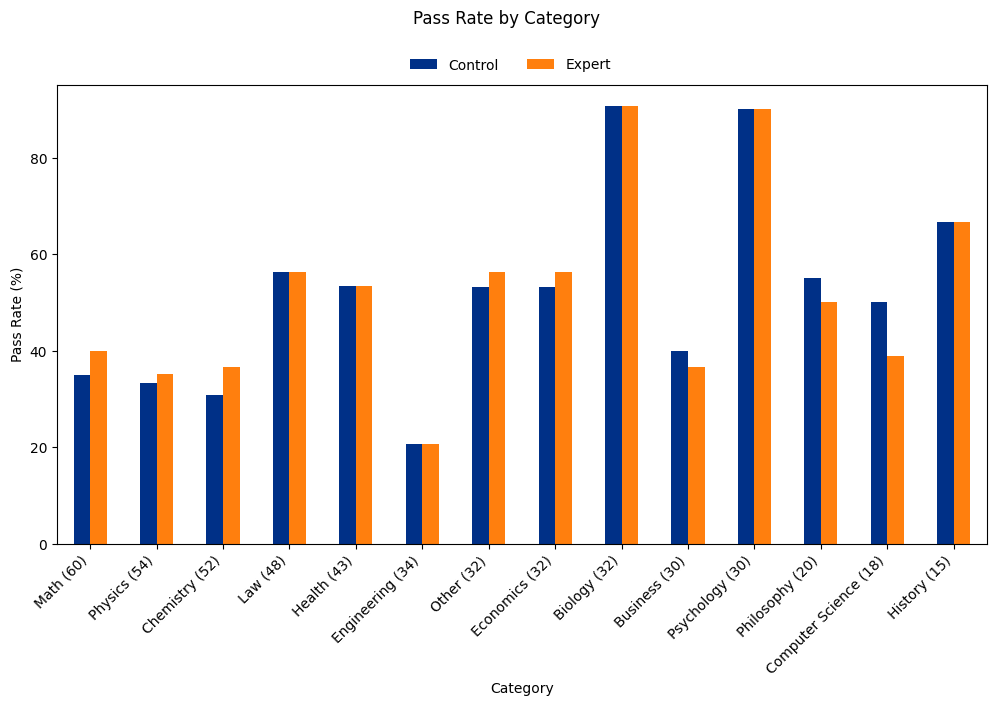

In [2]:
import matplotlib.pyplot as plt

# overall pass rate
control_pass_rate = round(float((filtered_df[filtered_df['is_expert']==False]['result']=='pass').mean()) * 100, 2)
expert_pass_rate = round(float((filtered_df[filtered_df['is_expert']==True]['result']=='pass').mean()) * 100, 2)

display(Math(
    rf'''
    \begin{{array}}{{l}} \\ \\ \mathbf{{Pass\ rates}} \\ \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Control pass rate}} = {control_pass_rate}\% \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Expert pass rate}} = {expert_pass_rate}\% \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Difference}} = {expert_pass_rate - control_pass_rate}\% \end{{array}}
    '''
))

# pass rate by category vizz
category_counts = (
    filtered_df.groupby('category')['question']
    .nunique()
)

pass_rate = (
    (filtered_df['result'] == 'pass')
    .groupby([filtered_df['category'], filtered_df['is_expert']])
    .mean()
    * 100
)

plot_df = pass_rate.unstack()

plot_df = plot_df.rename(columns={False: 'Control', True: 'Expert'})

ordered_categories = category_counts.sort_values(ascending=False).index
plot_df = plot_df.loc[ordered_categories]

formatted_names = {
    cat: cat.replace('_', ' ').replace('-', ' ').title()
    for cat in plot_df.index
}

plot_df.index = [
    f'{formatted_names[cat]} ({int(category_counts[cat])})'
    for cat in plot_df.index
]

fig, ax = plt.subplots(figsize=(12, 6))

plot_df.plot(kind='bar', ax=ax, color=['#003087', '#FF7F0E'])

ax.set_ylabel('Pass Rate (%)')
ax.set_xlabel('Category')

fig.suptitle('Pass Rate by Category', y=1)

ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.4875, 1),
    ncol=len(plot_df.columns),
    frameon=False
)

plt.xticks(rotation=45, ha='right')

plt.subplots_adjust(top=0.875)

plt.show()

## 🎲 Inferential statistics

#### Bootstrapping

This resampling method was chosen because the experiment was only run once using a limited number of questions. Bootstrapping helps us estimate the uncertainty around our observed effect size by repeatedly resampling the data (with replacement) and recomputing the evaluation metric. The resulting variation is treated as akin to that expected if the experiment were rerun on new data. If this variation is low, we can be more confident that the magnitude of our result reflects a true difference and not just luck of the draw.

#### Exact McNemar’s test

This statistical significance test was selected because the data is paired (each question is answered under control and expert persona conditions), the results are binary (pass or fail), the data can be arranged in a 2×2 table and the disagreement counts (cases where a question passes under one condition but fails under the other) are relatively low (making the standard McNemar's test less reliable). The Exact McNemar's test uses these disagreement counts to estimate the probability that our observed difference could have occurred by chance. If the expert persona truly has no effect, the disagreement counts would be expected to happen roughly equally in both directions and highly lopsided results would be less likely.
<br><br>

### 1) Bootstrapping implementation

Bootstrapping lets us take our evaluation metric, the expert persona pass rate minus the control pass rate, and quantify how confident we are that the magnitude of the result isn't just down to a lucky sample. The idea is that if we collected a new sample of data, the result would likely vary slightly by chance depending on which cases happened to be included. Bootstrapping simulates this variability without needing to collect new data. It works by resampling our existing dataset with replacement many times (typically 10,000), recomputing the evaluation metric on each resampled dataset and building up a distribution of the results. Sampling with replacement means each simulated dataset is the same size as the original, but some cases appear multiple times and others not at all — mimicking the kind of variation a genuinely new sample would show. The more spread out this distribution is, the less confident we can be in the magnitude of our observed result.

**Key terms:**

Mean difference = the average of our evaluation metric (expert persona pass rate minus the control pass rate) across all bootstrap simulations.

Bootstrap standard error = a measure of how much the result typically varies from one simulation to the next. 

> *Note: a larger value means more variation and greater uncertainty in the result.*

95% confidence interval = a range of values within which the evaluation metric falls 95% of the time under repeated resampling.

> *Note: A larger range means more variation and greater uncertainty in the result. Also, for our purposes, if the lower end of this range falls below 0, it severely limits our confidence in the efficacy of using an expert persona because a difference of 0 or less remains plausible.*

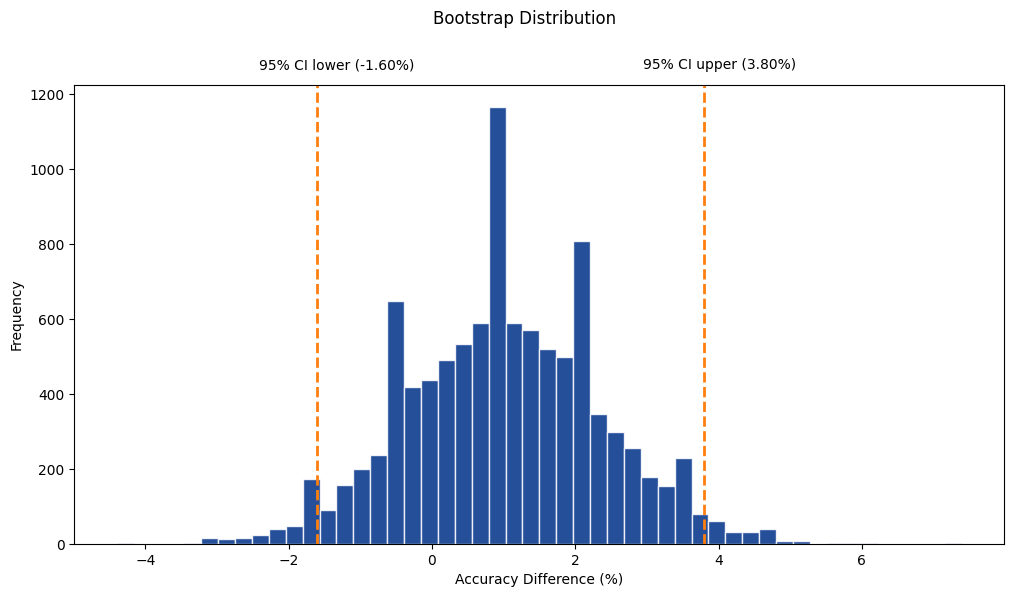

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...



...


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [3]:
import numpy as np


verbose = True
truncate_at = 5


# bootstrap calculation
paired = filtered_df.pivot(
    index='question',
    columns='is_expert',
    values='result'
)

paired.columns = ['control', 'expert']

paired = paired.reset_index()

paired['control'] = paired['control'] == 'pass'
paired["expert"] = paired['expert'] == 'pass'

rng = np.random.default_rng(seed=2026)

n = len(paired)
n_bootstrap = 10000

control = np.empty(n_bootstrap)
expert = np.empty(n_bootstrap)
results = np.empty(n_bootstrap)

for i in range(n_bootstrap):
    
    indices = rng.choice(n, size=n, replace=True)
    sample = paired.iloc[indices]

    control_accuracy = sample['control'].mean()
    expert_accuracy = sample['expert'].mean()

    control[i], expert[i] = control_accuracy, expert_accuracy
    
    difference = expert_accuracy - control_accuracy

    results[i] = difference * 100
            
ci = np.percentile(results, [2.5, 97.5])


# bootstrap distribution vizz
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(
    results,
    bins=50,
    color='#003087',
    edgecolor='white',
    alpha=0.85
)

ax.axvline(
    ci[0],
    color='#FF7F0E',
    linestyle='--',
    linewidth=2,
    label=f'95% CI lower ({ci[0]:.2f}%)'
)
ax.axvline(
    ci[1],
    color='#FF7F0E',
    linestyle='--',
    linewidth=2,
    label=f'95% CI upper ({ci[1]:.2f}%)'
)

ax.set_ylabel('Frequency')
ax.set_xlabel('Accuracy Difference (%)')
fig.suptitle('Bootstrap Distribution', y=1)
ax.legend(
    loc='lower center',
    bbox_to_anchor=(0.4875, 1),
    ncol=2,
    columnspacing=16.5,
    handlelength=0,
    handletextpad=0,
    frameon=False
)
plt.subplots_adjust(top=0.875)
plt.show()


# show results
for i, result in enumerate(results): 
    if i < truncate_at and verbose:
            display(Math(
                rf'''
                \begin{{array}}{{l}} \\ \\ \mathbf{{Resample\ {i+1}/{n_bootstrap}}} \\ \end{{array}}
                '''
            ))
            display(Math(
                rf'''
                \begin{{array}}{{l}} \text{{Control accuracy}} = {control[i] * 100:.2f}\% \end{{array}}
                '''
            ))
            display(Math(
                rf'''
                \begin{{array}}{{l}} \text{{Expert accuracy}} = {expert[i] * 100:.2f}\% \\ \end{{array}}
                '''
            ))
            display(Math(
                rf'''
                \begin{{array}}{{l}} \text{{Difference}} = {result:.2f}\% \end{{array}}
                '''
            ))
    
            if i + 1 == truncate_at:
                print('\n\n...')

display(Math(
    rf'''
    \begin{{array}}{{l}} \\ \\ \mathbf{{Bootstrap\ results}} \\ \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Mean difference}} = {results.mean():.2f}\% \end{{array}}
    '''
))

display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{Bootstrap SE}} = {results.std(ddof=1):.2f}\%  \end{{array}}
    '''
))
display(Math(
    rf'''
    \begin{{array}}{{l}} \text{{95\% CI}} = [{ci[0]:.2f}\%,\; {ci[1]:.2f}\%] \\ \\ \\ \\ \end{{array}}
    '''
))

### 2) Exact McNemar's test implementation

$$p = 2 \times \sum_{i=0}^{\min(b,c)} \binom{b+c}{i} \left(0.5\right)^{b+c}$$

**Where:**

$b$ = the number of questions where the *first* condition (e.g., control) got it right and the *second* condition (expert-persona) got it wrong.

$c$ = the number of questions where the *second* condition (expert-persona) got it right and the *first* condition (control) got it wrong.

$b + c$ = the total number of disagreements.

$i$ = a stand-in number representing the number of disagreements that went in a specific direction.

> *Note: this is used as a part of a loop where the theoretical probability of observing a result at each value of $i$ is calculated (see more on how this is done below). The loop begins at 0 and stops at the smaller of the two disagreement counts, $\min(b,c)$. This upper limit is selected because it represents outcomes as unlikely as or more than what we observed (we would normally expect a 50/50 split between $b$ or $c$ if there were really no difference between the conditions). These probabilities are then summed to give us the overall probability of observing a result as extreme as ours or more by chance alone (p-value).*

$\binom{b+c}{i}$ = out of the total disagreements, how many different ways could we have arranged exactly $i$ of those questions to favor a certain condition. The more theoretical combinations that can produce a specific outcome, the more likely it is. For example, you are more likely to roll a 7 than a 12 when using two dice because multiple combinations result in a 7 and only one a 12.

$\left(0.5\right)^{b+c}$ = the probability of any *one single, specific* sequence for $b + c$ disagreements. If the persona truly had no effect, each disagreement would have a 50/50 chance of going either way, hence the 0.5 assumption. The term above, $\binom{b+c}{i}$, is multiplied by this term to calculate the likelihood of a specific result based on the total disagreements.

> *Note: even when there are many potential ways of arranging $i$ questions to favour a certain condition, there will also be an exponentially larger pool of total possible arrangements if the number of total disagreements ($b + c$) is high. Using $\left(0.5\right)^{b+c}$ takes this into account and keeps the final result a valid probability rather than an ever-inflating count.* 

$\sum_{i=0}^{\min(b,c)}$ = adds up the probabilities of every outcome *at least as imbalanced* as what we actually saw in our experiment. We need this because a p-value isn't just "how likely is my exact result" — it's an answer to the question of "how likely would we be to observe a result this extreme *or worse* by chance alone?"

$2 \times$ = makes the test two-sided. This means it determines the likelihood that an imbalance of this magnitude could have occured in *either* direction (i.e. for all we knew, the expert persona could have helped or hindered LLM performance).

$p$ = the final probability (p-value). A small $p$ (conventionally < 0.05) means the split between $b$ and $c$ is unlikely to be due to chance alone.

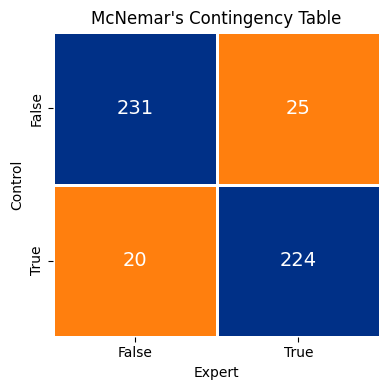

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

...

<IPython.core.display.Math object>

<IPython.core.display.Math object>



...


<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [4]:
from matplotlib.colors import ListedColormap
import seaborn as sns


verbose = True
truncate_at = 5


# contingency table vizz
table = pd.crosstab(
    paired['control'],
    paired['expert']
)

cmap = ListedColormap([
    '#FF7F0E',
    '#003087'
])

fig, ax = plt.subplots(figsize=(4, 4))
sns.heatmap(
    table,
    annot=True,
    fmt='d',
    cmap=cmap,
    cbar=False,
    linewidths=1,
    linecolor='white',
    annot_kws={'size': 14},
    ax=ax
)
ax.set_xlabel('Expert')
ax.set_ylabel('Control')
ax.set_title("McNemar's Contingency Table")
plt.tight_layout()
plt.show()


# calculate and show results
b = table.iloc[0, 1]
c = table.iloc[1, 0]
n = b + c

def comb(n, i):
    if i > n:
        return 0

    i = min(i, n - i)
    result = 1
    
    for j in range(1, i + 1):
            
        result = result * (n - i + j) // j
    
    return result

x = min(b, c)
p_value = 0

for i in range(x + 1):
    term = comb(n, i) * (0.5**n)
    
    if i < truncate_at and verbose:
        display(Math(
            rf'''
            \begin{{array}}{{l}} \\ \\ \mathbf{{i = {i}/{x}}} \\ \end{{array}} 
            '''
        ))
        display(Math(
            rf'''
            \begin{{array}}{{l}} p \; = \; p \; + \; \binom{{b+c}}{{i}} \left(0.5\right)^{{b+c}}
            \; = \; {p_value} \; + \; {term}
            \end{{array}} 
            '''
        ))


        if i + 1 == truncate_at:
            print('\n\n...')
        
    p_value += term

if verbose:
    display(Math(
        rf'''
            \begin{{array}}{{l}}
            \\ \\
            \mathbf{{Two-tailed\ test}} \\
            p \; = \; 2 \; \times \; p
            \; = \; 2 \; \times \; {min(1, p_value)}
            \\ \\
            \end{{array}} 
        '''
    ))

p_value = min(p_value * 2, 1)

display(Math(
    rf'''
        \begin{{array}}{{l}}
        \\
        \mathbf{{P-value}} \\
        {p_value}
        \\ \\
        \end{{array}} 
    '''
))